In [1]:
import numpy as np
import pandas as pd
from utils import plot_error_rate_polydegree,split_data, plot_regularized_error,plot_learning_curve

**Fixing high bias or underfitting problem of the model**

**Reading the file**

In [2]:
df = pd.read_csv('data/bias_variance_datasets.csv',header=None,names=['X','Y'])
df

,X,Y
0,1000.000000,128.784205
1,1030.303030,173.424277
2,1060.606061,180.256434
3,1090.909091,244.679476
4,1121.212121,143.460498
...,...,...
95,3878.787879,413.914702
96,3909.090909,371.400689
97,3939.393939,360.280911
98,3969.696970,325.133909


**Extracting the datas**

In [3]:
X = np.array(df[['X']])
Y = np.array(df['Y'])

**Splitting the datasets**

In [4]:
X_train,Y_train,X_cv,Y_cv,X_test,Y_test = split_data(X,Y)
print(f'The shape of the training data is: {X_train.shape}')
print(f'The shape of the cross_validation data is: {X_cv.shape}')
print(f'The shape of the test data is: {X_test.shape}')

The shape of the training data is: (60, 1)
The shape of the cross_validation data is: (20, 1)
The shape of the test data is: (20, 1)


**Plot of the training error and cross_Validation dataset error to study how well the model is performing**

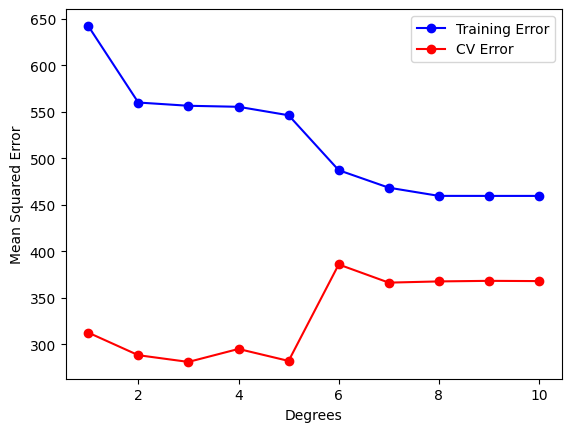

In [5]:
degrees=11
plot_error_rate_polydegree(degrees,X_train,X_cv,Y_train,Y_cv)

**As we can observe from the figure above that, with the increase in degree of polynomial, the training error is decreasing and gets low but the cross_valdiation error increases after degree 4 which means after degree 4 , we are facing the issue of high variance or overfitting of the model**

**So we can use the degree of 4 for polynomial engineering and we can also use the regularization for preventing the overfitting or high variance problem**

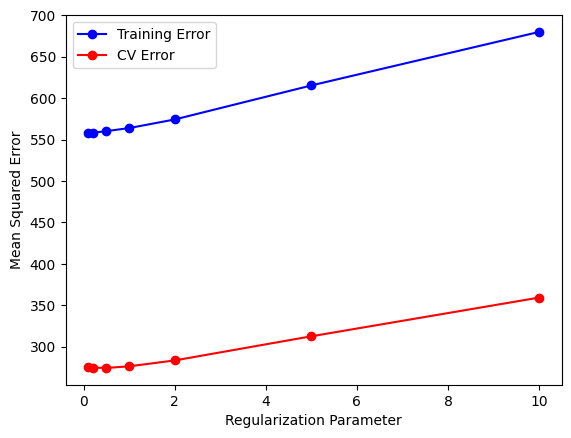

In [6]:
reg_params = [10, 5, 2, 1, 0.5, 0.2, 0.1]
degree = 5
plot_regularized_error(reg_params,degree,X_train,X_cv,Y_train,Y_cv)

**As we can see from the plot above that using the high value of lambda or regularization pattern penalized the larger coefficients heavily, that can cause the problem of high bias instead of preventing the problem of high variance**

**So we are using the smaller values of lambda, inorder to prevent the high bias or underfitting problem**

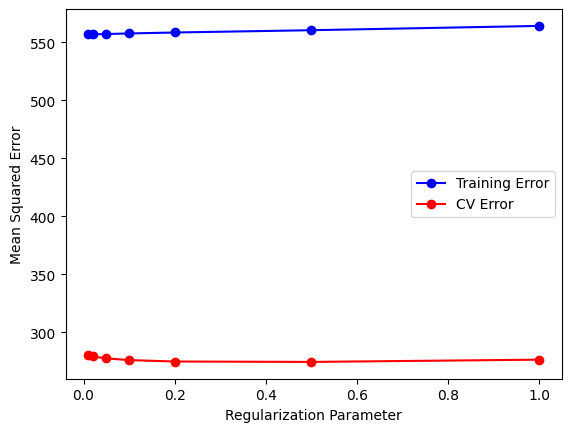

In [7]:
reg_params = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
plot_regularized_error(reg_params,degree,X_train,X_cv,Y_train,Y_cv)

**As the gap between the training and cross_validation error is still higher, even though the training error had decreased, cause our model isnot generalizing on the cross_valdiation datasets, so we are now increasing the training datasets for exposure of the model to more training examples**

**here we are adding more training examples but also added a new feature**

In [8]:
df = pd.read_csv('data/bias_var.csv',header=None,names=['f1','f2','Y'])
df

,f1,f2,Y
0,1000.000000,7.951952,243.120049
1,1003.003003,6.878879,238.326194
2,1006.006006,2.386386,164.545180
3,1009.009009,4.428428,183.882605
4,1012.012012,5.381381,204.439900
...,...,...,...
995,3987.987988,6.686687,426.100249
996,3990.990991,1.537538,336.833002
997,3993.993994,5.037037,352.886545
998,3996.996997,4.476476,330.779615


In [9]:
X = np.array(df[['f1','f2']])
Y = np.array(df['Y'])

In [10]:
X_train,Y_train,X_cv,Y_cv,X_test,Y_test = split_data(X,Y)
print(f'The shape of the training data is: {X_train.shape}')
print(f'The shape of the cross_validation data is: {X_cv.shape}')
print(f'The shape of the test data is: {X_test.shape}')

The shape of the training data is: (600, 2)
The shape of the cross_validation data is: (200, 2)
The shape of the test data is: (200, 2)


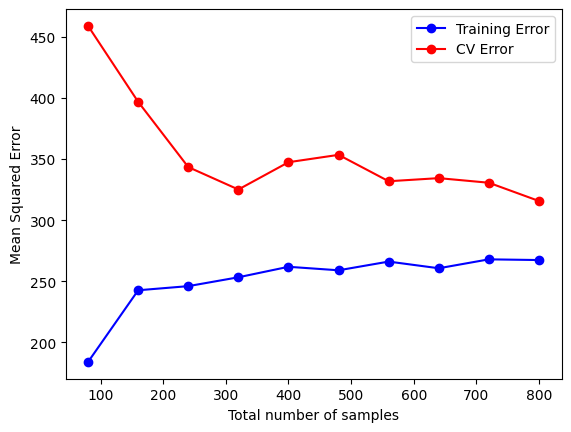

In [11]:
plot_learning_curve(degree,X_train,X_cv,Y_train,Y_cv)

**Here we can observe that, as the number of datas keep on increasing , the gap between training error and cross_validation error keeps on decreasing, and we came upto this point after finding the most effective degree of polynomial and also we made this new data after applying the regularizaion and using only 2 features**